original image
Random number: -31
original image size (293, 966, 3)
cropped image
cropped image shape (231, 904, 3)


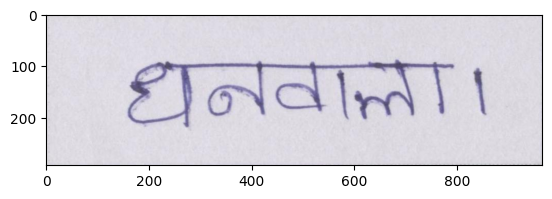

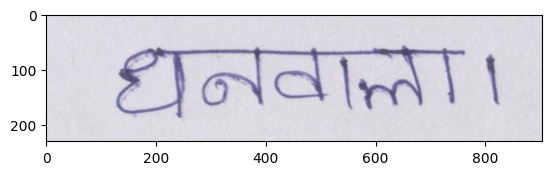

In [6]:
import random
from PIL import Image, ImageOps
import numpy as np
import matplotlib.pyplot as plt

# Load your image
image_path = '../data/hindi_data/images/000000001.png'  # replace with the path to your image
img = Image.open(image_path)
print(F'original image')
# plt.figure()
plt.imshow(img)
# plt.close()
# Generate a random number between -10 and 10
rand_num = random.randint(-50, 50)
print(f"Random number: {rand_num}")
# rand_num = 0
print(f'original image size {np.array(img).shape}')

# Calculate the average color of the boundary
def get_boundary_average_color(img):
    img_array = np.array(img)
    # Get boundary pixels (top, bottom, left, right edges)
    top_edge = img_array[0, :, :]
    bottom_edge = img_array[-1, :, :]
    left_edge = img_array[:, 0, :]
    right_edge = img_array[:, -1, :]
    # Concatenate all boundary pixels
    boundary_pixels = np.concatenate((top_edge, bottom_edge, left_edge, right_edge), axis=0)
    # Calculate the mean color
    avg_color = boundary_pixels.mean(axis=0).astype(int)
    return tuple(avg_color)

avg_color = get_boundary_average_color(img)

if rand_num < 0:
    # Crop image by |rand_num| pixels on each side
    crop_pixels = abs(rand_num)
    width, height = img.size
    img = img.crop((crop_pixels, crop_pixels, width - crop_pixels, height - crop_pixels))

elif rand_num > 0:
    # Pad image by rand_num pixels on each side with the average boundary color
    img = ImageOps.expand(img, border=rand_num, fill=avg_color)

# Show and save the image
# img.show()
print(f'cropped image')
plt.figure()
plt.imshow(img)
print(F'cropped image shape {np.array(img).shape}')
# plt.close()
#output_path = 'modified_image.jpg'
#img.save(output_path)
#print(f"Image saved as {output_path}")


Processing 000000009.png with random number: 14
Saved augmented image to ../output/cropped/images/cropped_000000009.png
original image 000000009.png shape (293, 759, 3)
cropped image 000000009.png shape (321, 787, 3)


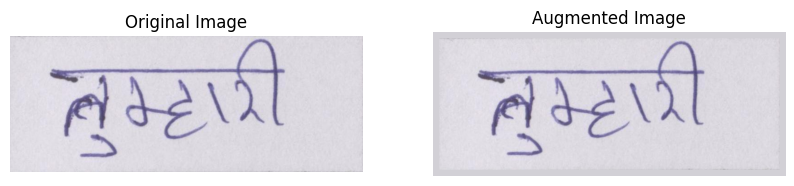

Processing 000000007.png with random number: 12
Saved augmented image to ../output/cropped/images/cropped_000000007.png
original image 000000007.png shape (293, 718, 3)
cropped image 000000007.png shape (317, 742, 3)


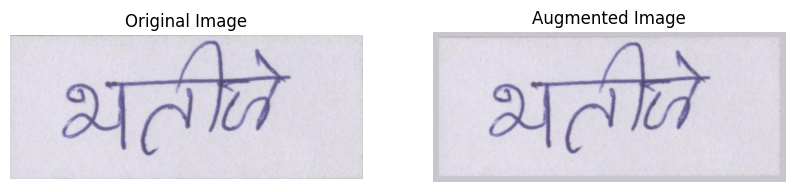

Processing 000000005.png with random number: -19
Saved augmented image to ../output/cropped/images/cropped_000000005.png
original image 000000005.png shape (292, 688, 3)
cropped image 000000005.png shape (254, 650, 3)


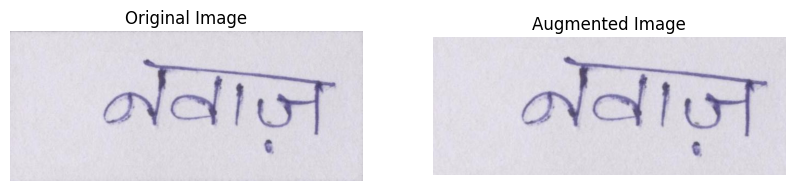

Processing 000000003.png with random number: -19
Saved augmented image to ../output/cropped/images/cropped_000000003.png
original image 000000003.png shape (294, 702, 3)
cropped image 000000003.png shape (256, 664, 3)


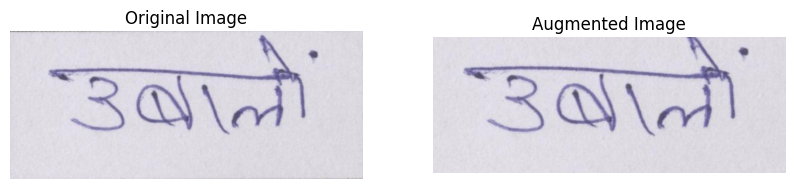

Processing 000000006.png with random number: 40
Saved augmented image to ../output/cropped/images/cropped_000000006.png
original image 000000006.png shape (293, 880, 3)
cropped image 000000006.png shape (373, 960, 3)


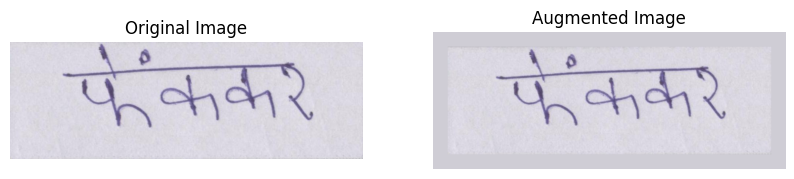

Processing 000000001.png with random number: 16
Saved augmented image to ../output/cropped/images/cropped_000000001.png
original image 000000001.png shape (293, 966, 3)
cropped image 000000001.png shape (325, 998, 3)


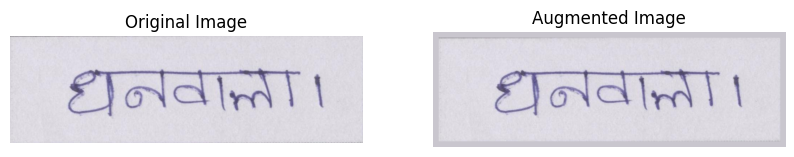

Processing 000000004.png with random number: 16
Saved augmented image to ../output/cropped/images/cropped_000000004.png
original image 000000004.png shape (293, 1281, 3)
cropped image 000000004.png shape (325, 1313, 3)


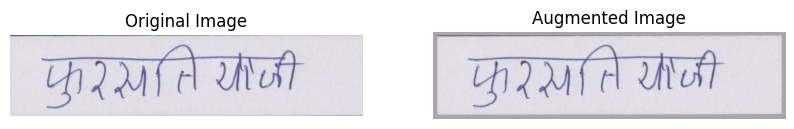

Processing 000000008.png with random number: 49
Saved augmented image to ../output/cropped/images/cropped_000000008.png
original image 000000008.png shape (292, 517, 3)
cropped image 000000008.png shape (390, 615, 3)


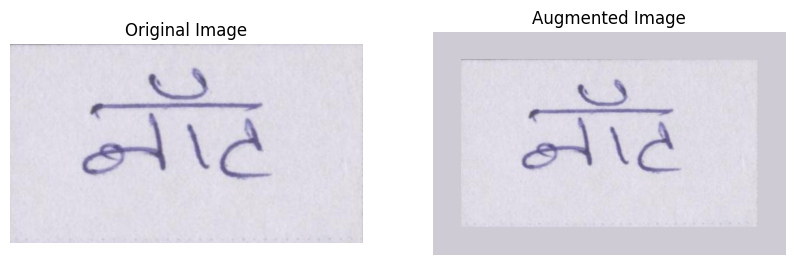

Processing 000000002.png with random number: 7
Saved augmented image to ../output/cropped/images/cropped_000000002.png
original image 000000002.png shape (292, 795, 3)
cropped image 000000002.png shape (306, 809, 3)


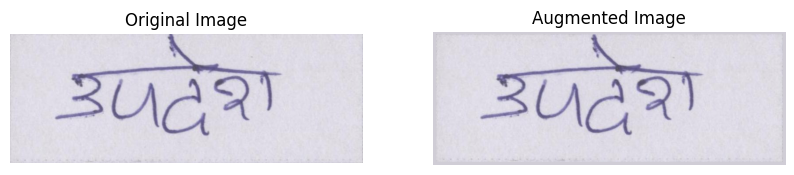

Augmentation completed for all images in the folder.


In [7]:
import os
import random
from PIL import Image, ImageOps
import numpy as np
np.random.seed(123)
# Paths for the input and output folders
input_folder = '../data/hindi_data/images/'  # Replace with the path to your source folder
output_folder = '../output/cropped/images/'  # Replace with the path to your output folder

# Ensure the output directory exists
os.makedirs(output_folder, exist_ok=True)

# Function to calculate the average boundary color
def get_boundary_average_color(img):
    img_array = np.array(img)
    top_edge = img_array[0, :, :]
    bottom_edge = img_array[-1, :, :]
    left_edge = img_array[:, 0, :]
    right_edge = img_array[:, -1, :]
    boundary_pixels = np.concatenate((top_edge, bottom_edge, left_edge, right_edge), axis=0)
    avg_color = boundary_pixels.mean(axis=0).astype(int)
    return tuple(avg_color)

# Process each image in the input folder
for filename in os.listdir(input_folder):
    if filename.endswith(('.jpg', '.jpeg', '.png', '.bmp', '.tiff')):  # Specify image formats you want to process
        img_path = os.path.join(input_folder, filename)
        img = Image.open(img_path)
        original_img = img
        # Generate a random number between -10 and 10 for augmentation
        rand_num = random.randint(-50, 50)
        print(f"Processing {filename} with random number: {rand_num}")

        # Augmentation logic based on random number
        if rand_num < 0:
            # Crop image by |rand_num| pixels on each side
            crop_pixels = abs(rand_num)
            width, height = img.size
            img = img.crop((crop_pixels, crop_pixels, width - crop_pixels, height - crop_pixels))
        
        elif rand_num > 0:
            # Pad image by rand_num pixels on each side with the average boundary color
            avg_color = get_boundary_average_color(img)
            img = ImageOps.expand(img, border=rand_num, fill=avg_color)
        
        # Save the augmented image to the output folder
        output_path = os.path.join(output_folder, f"cropped_{filename}")
        img.save(output_path)
        print(f"Saved augmented image to {output_path}")
        print(f'original image {filename} shape {np.array(original_img).shape}')
        print(f'cropped image {filename} shape {np.array(img).shape}')
        # Display the original and augmented images side by side
        fig, axes = plt.subplots(1, 2, figsize=(10, 5))
        axes[0].imshow(original_img)
        axes[0].set_title("Original Image")
        axes[0].axis("off")

        axes[1].imshow(img)
        axes[1].set_title("Augmented Image")
        axes[1].axis("off")

        plt.show()
print("Augmentation completed for all images in the folder.")


In [ ]:
import os
import random
from PIL import Image, ImageOps
import numpy as np
import matplotlib.pyplot as plt

# Set random seed for reproducibility
np.random.seed(123)

# Paths for the input and output folders
input_folder = '../data/hindi_data/images/'  # Replace with the path to your source folder
output_folder = '../output/cropped/images/'  # Replace with the path to your output folder
label_file_path = '../output/cropped/gt_file.txt'  # Path to save labels file

# Ensure the output directory exists
os.makedirs(output_folder, exist_ok=True)

# Function to calculate the average boundary color
def get_boundary_average_color(img):
    img_array = np.array(img)
    top_edge = img_array[0, :, :]
    bottom_edge = img_array[-1, :, :]
    left_edge = img_array[:, 0, :]
    right_edge = img_array[:, -1, :]
    boundary_pixels = np.concatenate((top_edge, bottom_edge, left_edge, right_edge), axis=0)
    avg_color = boundary_pixels.mean(axis=0).astype(int)
    return tuple(avg_color)

# Open label file for writing
with open(label_file_path, 'w') as label_file:
    # Process each image in the input folder
    for filename in os.listdir(input_folder):
        if filename.endswith(('.jpg', '.jpeg', '.png', '.bmp', '.tiff')):  # Specify image formats you want to process
            img_path = os.path.join(input_folder, filename)
            img = Image.open(img_path)
            original_img = img.copy()

            # Generate a random number between -10 and 10 for augmentation
            rand_num = random.randint(-50, 50)
            print(f"Processing {filename} with random number: {rand_num}")

            # Augmentation logic based on random number
            if rand_num < 0:
                # Crop image by |rand_num| pixels on each side
                crop_pixels = abs(rand_num)
                width, height = img.size
                img = img.crop((crop_pixels, crop_pixels, width - crop_pixels, height - crop_pixels))
                label = f"Cropped by {crop_pixels}px on each side"
            elif rand_num > 0:
                # Pad image by rand_num pixels on each side with the average boundary color
                avg_color = get_boundary_average_color(img)
                img = ImageOps.expand(img, border=rand_num, fill=avg_color)
                label = f"Padded by {rand_num}px on each side with color {avg_color}"
            else:
                label = "No change"

            # Save the augmented image to the output folder
            output_path = os.path.join(output_folder, f"augmented_{filename}")
            img.save(output_path)
            print(f"Saved augmented image to {output_path}")
            print(f'Original image {filename} shape {np.array(original_img).shape}')
            print(f'Augmented image {filename} shape {np.array(img).shape}')

            # Write image path and augmentation label to the text file
            label_file.write(f"{output_path}\t{label}\n")

            # Display the original and augmented images side by side
            fig, axes = plt.subplots(1, 2, figsize=(10, 5))
            axes[0].imshow(original_img)
            axes[0].set_title("Original Image")
            axes[0].axis("off")

            axes[1].imshow(img)
            axes[1].set_title("Augmented Image")
            axes[1].axis("off")

            plt.show()

print("Augmentation completed for all images in the folder.")


augmenting images:   0%|          | 0/9 [00:00<?, ?it/s]

Processing 000000009.png with random number: 32


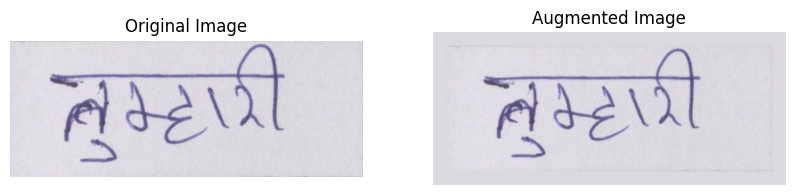

augmenting images:  11%|█         | 1/9 [00:00<00:01,  6.58it/s]

Processing 000000007.png with random number: 43


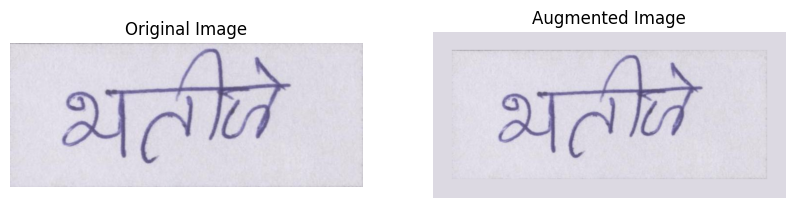

augmenting images:  22%|██▏       | 2/9 [00:00<00:01,  6.69it/s]

Processing 000000005.png with random number: -17


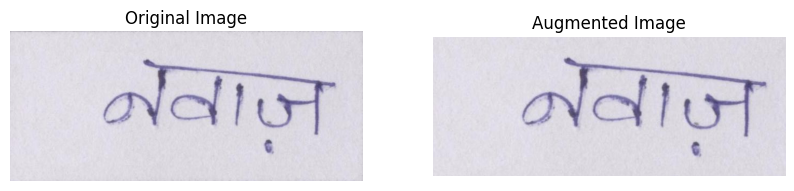

augmenting images:  33%|███▎      | 3/9 [00:00<00:00,  7.16it/s]

Processing 000000003.png with random number: 36


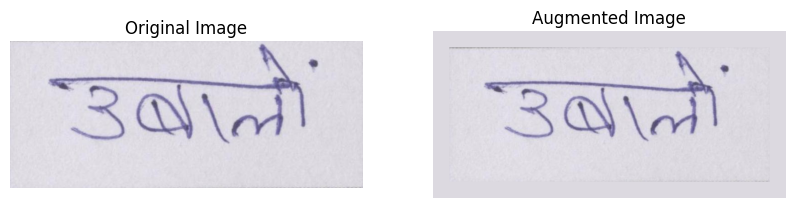

augmenting images:  44%|████▍     | 4/9 [00:00<00:00,  7.09it/s]

Processing 000000006.png with random number: 26


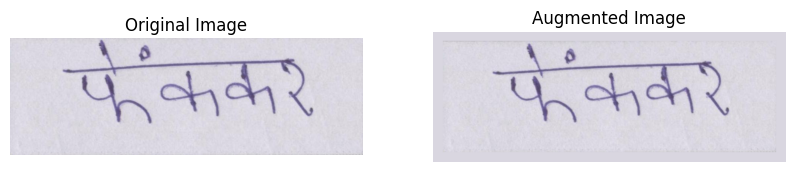

augmenting images:  56%|█████▌    | 5/9 [00:00<00:00,  6.79it/s]

Processing 000000001.png with random number: 44


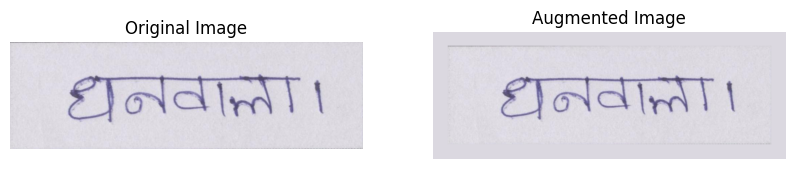

augmenting images:  67%|██████▋   | 6/9 [00:00<00:00,  6.65it/s]

Processing 000000004.png with random number: -28


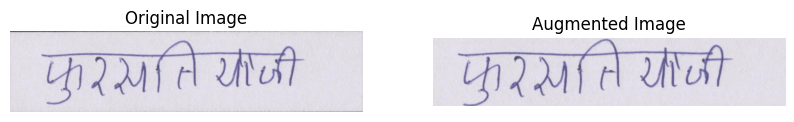

augmenting images:  78%|███████▊  | 7/9 [00:01<00:00,  6.65it/s]

Processing 000000008.png with random number: -33


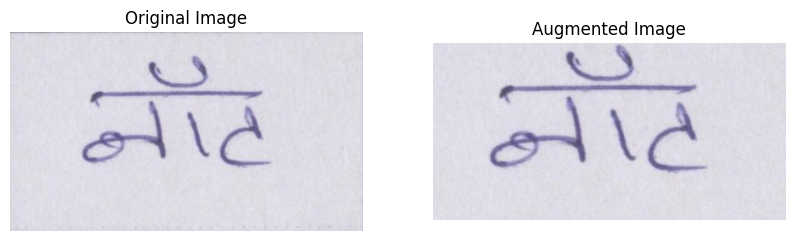

augmenting images:  89%|████████▉ | 8/9 [00:01<00:00,  6.42it/s]

Processing 000000002.png with random number: -7


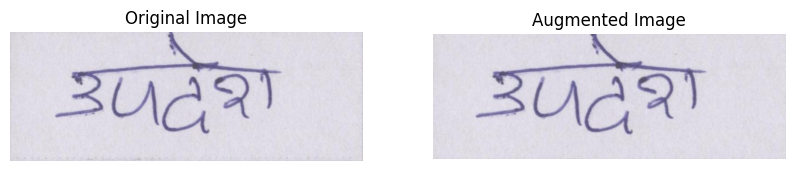

augmenting images: 100%|██████████| 9/9 [00:01<00:00,  6.69it/s]

Augmentation completed for all images in the folder.


In [25]:
import os
import random
from PIL import Image, ImageOps
import numpy as np
import matplotlib.pyplot as plt
from tqdm import tqdm 
# Set random seed for reproducibility
np.random.seed(123)

# Paths for the input and output folders
root_folder = '../data/sample_data/'
input_imgs_folder = os.path.join(root_folder, 'images')
input_gt_file_path = os.path.join(root_folder, 'gt_file.txt')

output_root = '../output/sample_data/pad/'
output_imgs_folder = os.path.join(output_root, 'images')
output_gt_file_path = os.path.join(output_root, 'gt_file.txt')

# Ensure the output directory exists
os.makedirs(output_root, exist_ok=True)
os.makedirs(output_imgs_folder, exist_ok=True)

# Function to calculate the average boundary color
def get_boundary_average_color(img):
    img_array = np.array(img)
    height, width, _ = img_array.shape

    # Calculate 10% of height and width
    h_margin = max(1, height // 10)  # At least 1 pixel to avoid zero margins
    w_margin = max(1, width // 10)

    # Extract 10% edge regions
    top_edge = img_array[:h_margin, :, :]
    bottom_edge = img_array[-h_margin:, :, :]
    left_edge = img_array[:, :w_margin, :]
    right_edge = img_array[:, -w_margin:, :]

    # Combine all edge pixels
    boundary_pixels = np.concatenate((top_edge.reshape(-1, 3), 
                                       bottom_edge.reshape(-1, 3), 
                                       left_edge.reshape(-1, 3), 
                                       right_edge.reshape(-1, 3)), axis=0)
    
    # Calculate average color
    avg_color = boundary_pixels.mean(axis=0).astype(int)
    return tuple(avg_color)


# Load ground truth labels from gt_file.txt
image_labels = {}
with open(input_gt_file_path, 'r') as gt_file:
    for line in gt_file:
        parts = line.strip().split(' ')  # Split by space
        if len(parts) == 2:
            image_name, label = parts
            image_labels[image_name] = label

# Process each image in the input folder
with open(output_gt_file_path, 'w') as label_file:
    for filename in tqdm(os.listdir(input_imgs_folder), desc='augmenting images'):
        if filename.endswith(('.jpg', '.jpeg', '.png', '.bmp', '.tiff')):  # Specify image formats you want to process
            img_path = os.path.join(input_imgs_folder, filename)
            img = Image.open(img_path)
            original_img = img.copy()

            # Generate a random number between -10 and 10 for augmentation
            rand_num = random.randint(-50, 50)
            print(f"Processing {filename} with random number: {rand_num}")

            # Augmentation logic based on random number
            if rand_num < 0:
                # Crop image by |rand_num| pixels on each side
                crop_pixels = abs(rand_num)
                width, height = img.size
                img = img.crop((crop_pixels, crop_pixels, width - crop_pixels, height - crop_pixels))
            elif rand_num > 0:
                # Pad image by rand_num pixels on each side with the average boundary color
                avg_color = get_boundary_average_color(img)
                img = ImageOps.expand(img, border=rand_num, fill=avg_color)
            # Else, no augmentation is performed

            # Save the augmented image to the output folder
            output_filename = f"augmented_{filename}"
            output_path = os.path.join(output_imgs_folder, output_filename)
            img.save(output_path)

            # Retrieve label from ground truth and save as a text file in the required format
            label = image_labels.get(filename, "Unknown")  # Default to "Unknown" if not found
            label_entry = f"{output_filename} {label}\n"  # Use space as the separator
            label_file.write(label_entry)

            # Display the original and augmented images side by side
            fig, axes = plt.subplots(1, 2, figsize=(10, 5))
            axes[0].imshow(original_img)
            axes[0].set_title("Original Image")
            axes[0].axis("off")

            axes[1].imshow(img)
            axes[1].set_title("Augmented Image")
            axes[1].axis("off")

            plt.show()

print("Augmentation completed for all images in the folder.")


# blurring code

augmenting images:   0%|          | 0/9 [00:00<?, ?it/s]

random number 3


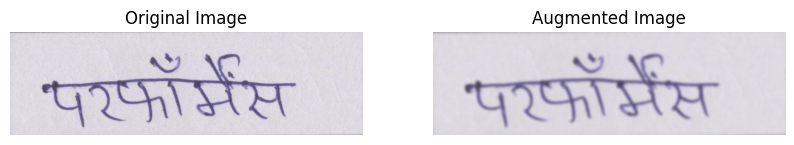

augmenting images:  11%|█         | 1/9 [00:00<00:01,  7.32it/s]

random number 4


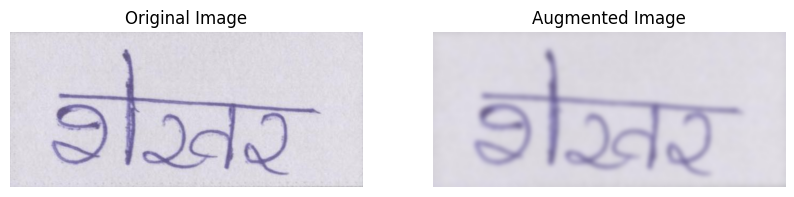

augmenting images:  22%|██▏       | 2/9 [00:00<00:00,  8.39it/s]

random number 2


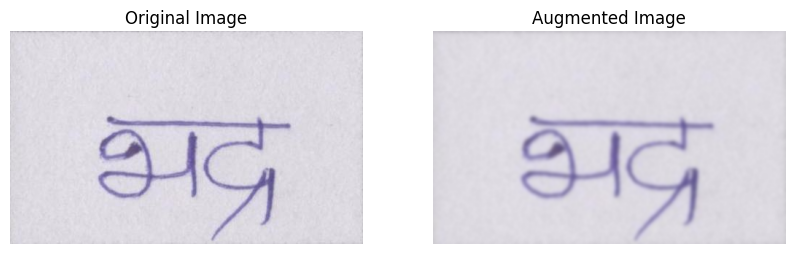

augmenting images:  33%|███▎      | 3/9 [00:00<00:00,  8.48it/s]

random number 2


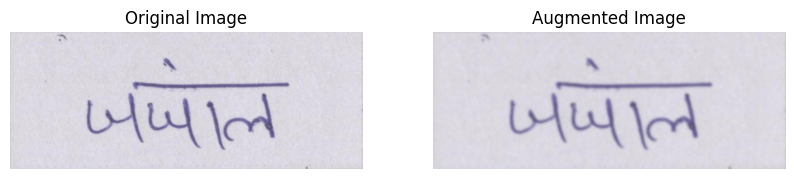

augmenting images:  44%|████▍     | 4/9 [00:00<00:00,  8.66it/s]

random number 2


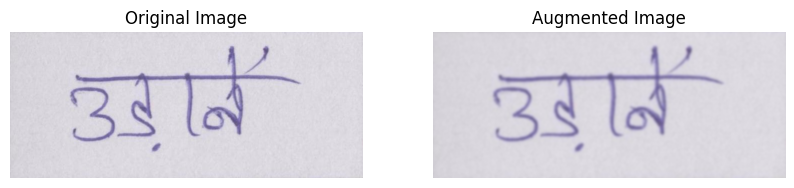

augmenting images:  56%|█████▌    | 5/9 [00:00<00:00,  8.89it/s]

random number 1


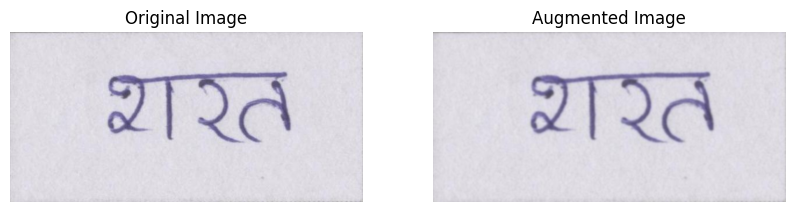

augmenting images:  67%|██████▋   | 6/9 [00:00<00:00,  8.80it/s]

random number 4


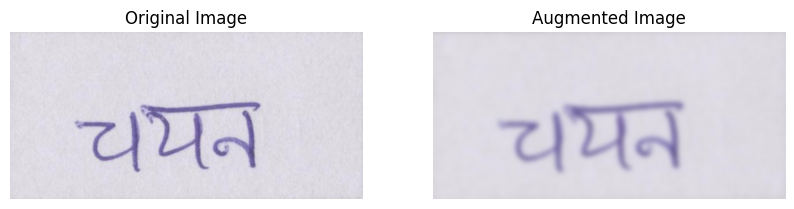

augmenting images:  78%|███████▊  | 7/9 [00:00<00:00,  8.53it/s]

random number 5


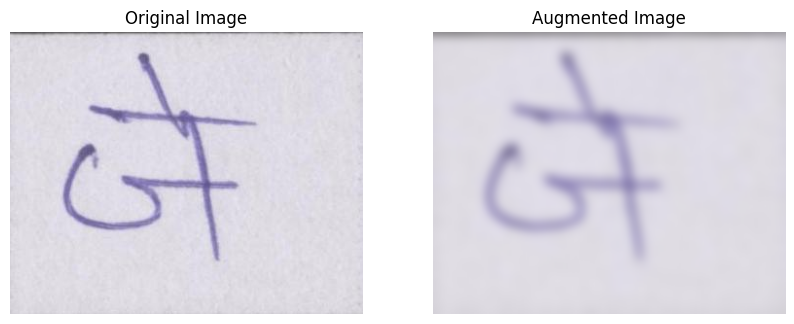

augmenting images:  89%|████████▉ | 8/9 [00:00<00:00,  7.68it/s]

random number 5


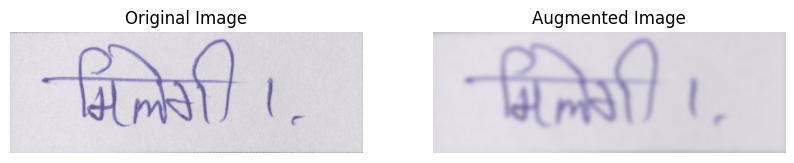

augmenting images: 100%|██████████| 9/9 [00:01<00:00,  8.31it/s]

Augmentation completed for all images in the folder.


In [2]:
import os
import random
from PIL import Image, ImageFilter
import numpy as np
from tqdm import tqdm 
import matplotlib.pyplot as plt

# Set random seed for reproducibility
np.random.seed(123)

# Paths for the input and output folders
root_folder = '/home/lalitha/17_PARSeq_Github/PARSeq_Indic_HTR/basic_data/hindi/train'  # edit: change file names here 
input_imgs_folder = os.path.join(root_folder, 'images')
input_gt_file_path = os.path.join(root_folder, 'gt_file.txt')

output_root = '../output/sample_data/blur/'  # edit: change file names here 
output_imgs_folder = os.path.join(output_root, 'images')
output_gt_file_path = os.path.join(output_root, 'gt_file.txt')

# Ensure the output directory exists
os.makedirs(output_root, exist_ok=True)
os.makedirs(output_imgs_folder, exist_ok=True)

# Load ground truth labels from gt_file.txt
image_labels = {}
with open(input_gt_file_path, 'r') as gt_file:
    for line in gt_file:
        parts = line.strip().split(' ')  # Split by space
        if len(parts) == 2:
            image_name, label = parts
            image_labels[image_name] = label

# Process each image in the input folder
with open(output_gt_file_path, 'w') as label_file:
    for filename in tqdm(os.listdir(input_imgs_folder), desc='augmenting images'):
        if filename.endswith(('.jpg', '.jpeg', '.png', '.bmp', '.tiff')):  # Specify image formats you want to process
            img_path = os.path.join(input_imgs_folder, filename)
            img = Image.open(img_path)
            original_img = img.copy()

            # Generate a random blur radius between 1 and 5
            blur_radius = random.randint(1, 5)
            print(f'random number {blur_radius}')

            # Apply Gaussian blur to the image
            img = img.filter(ImageFilter.GaussianBlur(blur_radius))

            # Save the augmented image to the output folder
            output_filename = f"blurred_{filename}"
            output_path = os.path.join(output_imgs_folder, output_filename)
            # img.save(output_path)

            # Retrieve label from ground truth and save as a text file in the required format
            label = image_labels.get(filename, "Unknown")  # Default to "Unknown" if not found
            label_entry = f"{output_filename} {label}\n"  # Use space as the separator
            # label_file.write(label_entry)

            # Display the original and augmented images side by side
            fig, axes = plt.subplots(1, 2, figsize=(10, 5))
            axes[0].imshow(original_img)
            axes[0].set_title("Original Image")
            axes[0].axis("off")

            axes[1].imshow(img)
            axes[1].set_title("Augmented Image")
            axes[1].axis("off")

            plt.show()

print("Augmentation completed for all images in the folder.")


# rotation code


augmenting images:   0%|          | 0/9 [00:00<?, ?it/s]

average color <class 'tuple'>
rotation angle 7.996141883363293


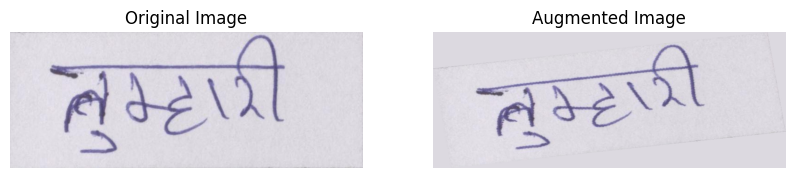

augmenting images:  11%|█         | 1/9 [00:00<00:01,  5.65it/s]

average color <class 'tuple'>
rotation angle 4.758227392423294


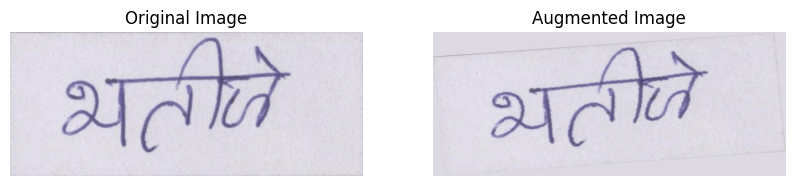

augmenting images:  22%|██▏       | 2/9 [00:00<00:01,  6.38it/s]

average color <class 'tuple'>
rotation angle 12.513486399224675


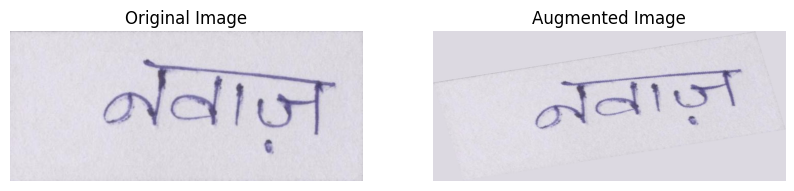

augmenting images:  33%|███▎      | 3/9 [00:00<00:00,  6.59it/s]

average color <class 'tuple'>
rotation angle 4.6761591834185126


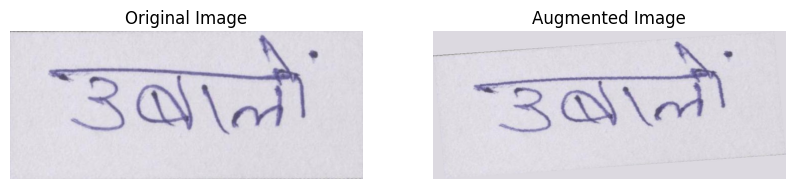

augmenting images:  44%|████▍     | 4/9 [00:00<00:00,  6.69it/s]

average color <class 'tuple'>
rotation angle 12.417763054475074


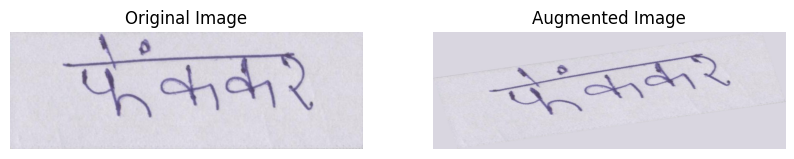

augmenting images:  56%|█████▌    | 5/9 [00:00<00:00,  6.75it/s]

average color <class 'tuple'>
rotation angle 0.18803738643795143


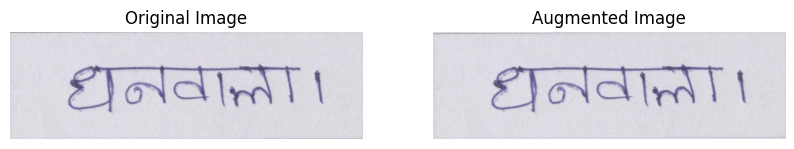

augmenting images:  67%|██████▋   | 6/9 [00:00<00:00,  6.59it/s]

average color <class 'tuple'>
rotation angle -6.724021765145739


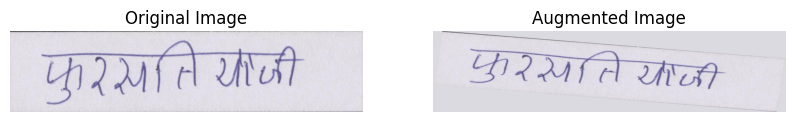

augmenting images:  78%|███████▊  | 7/9 [00:01<00:00,  6.36it/s]

average color <class 'tuple'>
rotation angle -28.735365659738463


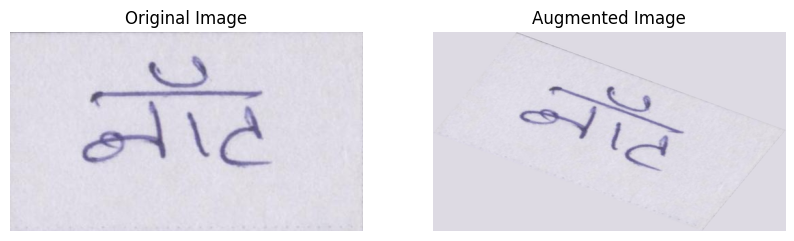

augmenting images:  89%|████████▉ | 8/9 [00:01<00:00,  6.73it/s]

average color <class 'tuple'>
rotation angle 5.830841850535592


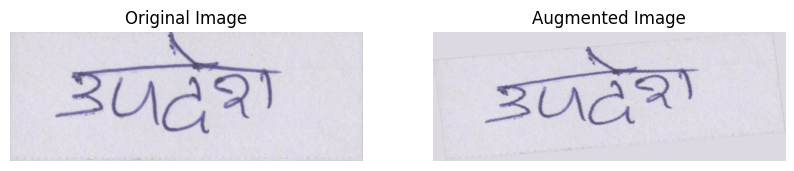

augmenting images: 100%|██████████| 9/9 [00:01<00:00,  6.61it/s]

Augmentation completed for all images in the folder.


In [24]:
import os
import random
from PIL import Image
import numpy as np
from tqdm import tqdm 

# Set random seed for reproducibility
np.random.seed(123)

# Paths for the input and output folders
root_folder = '../data/sample_data/'  # edit: change file names here 
input_imgs_folder = os.path.join(root_folder, 'images')
input_gt_file_path = os.path.join(root_folder, 'gt_file.txt')

output_root = '../output/sample_data/rotated/'  # edit: change file names here 
output_imgs_folder = os.path.join(output_root, 'images')
output_gt_file_path = os.path.join(output_root, 'gt_file.txt')

# Ensure the output directory exists
os.makedirs(output_root, exist_ok=True)
os.makedirs(output_imgs_folder, exist_ok=True)

# Load ground truth labels from gt_file.txt
image_labels = {}
with open(input_gt_file_path, 'r') as gt_file:
    for line in gt_file:
        parts = line.strip().split(' ')  # Split by space
        if len(parts) == 2:
            image_name, label = parts
            image_labels[image_name] = label
def get_boundary_average_color(img):
    img_array = np.array(img)
    height, width, _ = img_array.shape

    # Calculate 10% of height and width
    h_margin = max(1, height // 10)  # At least 1 pixel to avoid zero margins
    w_margin = max(1, width // 10)

    # Extract 10% edge regions
    top_edge = img_array[:h_margin, :, :]
    bottom_edge = img_array[-h_margin:, :, :]
    left_edge = img_array[:, :w_margin, :]
    right_edge = img_array[:, -w_margin:, :]

    # Combine all edge pixels
    boundary_pixels = np.concatenate((top_edge.reshape(-1, 3), 
                                       bottom_edge.reshape(-1, 3), 
                                       left_edge.reshape(-1, 3), 
                                       right_edge.reshape(-1, 3)), axis=0)
    
    # Calculate average color
    avg_color = boundary_pixels.mean(axis=0).astype(int)
    return tuple(avg_color)

# Process each image in the input folder
with open(output_gt_file_path, 'w') as label_file:
    for filename in tqdm(os.listdir(input_imgs_folder), desc='augmenting images'):
        if filename.endswith(('.jpg', '.jpeg', '.png', '.bmp', '.tiff')):  # Specify image formats you want to process
            img_path = os.path.join(input_imgs_folder, filename)
            img = Image.open(img_path)
            original_width, original_height = img.size
            original_img = img.copy()
            avg_color = get_boundary_average_color(img)
            print(f'average color {type(avg_color)}')

            # Generate a random rotation angle between 0 and 30 degrees
            rotation_angle = random.uniform(-30, 30)
            print(f'rotation angle {rotation_angle}')
    

            # Apply rotation
            img = img.rotate(rotation_angle, expand=True, fillcolor=(avg_color[0], avg_color[1], avg_color[2]))  # Fill with white
            img = img.resize((original_width, original_height), Image.Resampling.LANCZOS)
            # Save the augmented image to the output folder
            output_filename = f"rotated_{filename}"
            output_path = os.path.join(output_imgs_folder, output_filename)
            img.save(output_path)

            # Retrieve label from ground truth and save as a text file in the required format
            label = image_labels.get(filename, "Unknown")  # Default to "Unknown" if not found
            label_entry = f"{output_filename} {label}\n"  # Use space as the separator
            label_file.write(label_entry)
            # Display the original and augmented images side by side
            fig, axes = plt.subplots(1, 2, figsize=(10, 5))
            axes[0].imshow(original_img)
            axes[0].set_title("Original Image")
            axes[0].axis("off")

            axes[1].imshow(img)
            axes[1].set_title("Augmented Image")
            axes[1].axis("off")

            plt.show()

print("Augmentation completed for all images in the folder.")
